In [1]:
! pip install pandas rapidfuzz

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd

# Load the CSV file
file_path = r"C:\Users\USER\OneDrive\Desktop\freelancer_cleaned.csv"
df = pd.read_csv(file_path)

# Print all column names
print(df.columns.tolist())


['id', 'job_title', 'job_description', 'job_tags', 'days_left_to_expire', 'bit_amount', 'number_of_bits', 'verified_job', 'scraped_on', 'search_key', 'hash_key_value']


In [4]:
import pandas as pd

# Load the CSV file
file_path = r"C:/Users/USER/OneDrive/Desktop/naukri_posts_cleaned.csv"
df = pd.read_csv(file_path)

# Print all column names
print(df.columns.tolist())

['id', 'job_title', 'job_description', 'company_name', 'company_rating', 'company_reviews', 'job_tags', 'work_experience', 'salary', 'job_type', 'location', 'posted_on_raw_data', 'job_details', 'qualification', 'scraped_on', 'search_key']


In [ ]:
import pandas as pd
import hashlib
import re

# Load both data
df_freelancer = pd.read_csv(r"C:/Users/USER/OneDrive/Desktop/Work/CSV/freelancer_cleaned.csv")
df_naukri = pd.read_csv(r"C:/Users/USER/OneDrive/Desktop/naukri_posts_cleaned.csv")

# Remove duplicates in freelancer using 'hash_key_value'
df_freelancer = df_freelancer.drop_duplicates(subset='hash_key_value')

# Create a consistent hash key for Naukri dataset
def generate_hash(row):
    unique_str = (str(row['job_title']) + str(row['job_description']) +
                  str(row['company_name']) + str(row['job_tags']) +
                  str(row['search_key']))
    return hashlib.sha256(unique_str.encode('utf-8')).hexdigest()

df_naukri['hash_key_value'] = df_naukri.apply(generate_hash, axis=1)

# Remove duplicates from Naukri based on hash
df_naukri = df_naukri.drop_duplicates(subset='hash_key_value')

# Align common columns for combination
common_columns = ['job_title', 'job_description', 'job_tags', 'scraped_on', 'search_key', 'hash_key_value']

df_freelancer_clean = df_freelancer[common_columns].copy()
df_naukri_clean = df_naukri[common_columns].copy()

# Add a source column
df_freelancer_clean['source'] = 'freelancer'
df_naukri_clean['source'] = 'naukri'

# Combine datasets
df_combined = pd.concat([df_freelancer_clean, df_naukri_clean], ignore_index=True)

# Step 7: Remove illegal characters
def remove_illegal_chars(text):
    if isinstance(text, str):
        return re.sub(r"[\x00-\x1F\x7F]", "", text)
    return text

for col in df_combined.select_dtypes(include='object').columns:
    df_combined[col] = df_combined[col].apply(remove_illegal_chars)

# Step 8: Save to CSV
output_path = r"C:/Users/USER/OneDrive/Desktop/combined_jobs.csv"
df_combined.to_csv(output_path, index=False, encoding='utf-8')

print("Combined dataset saved successfully to:", output_path)


Combined dataset saved successfully to: C:/Users/USER/OneDrive/Desktop/combined_jobs.csv


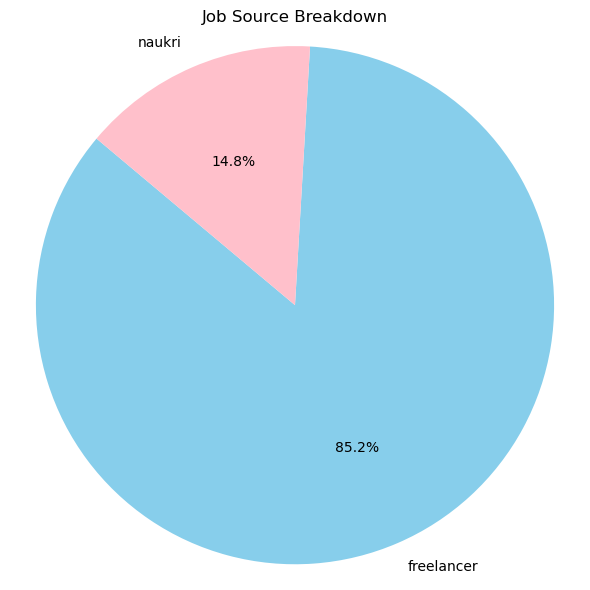

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned CSV
df = pd.read_csv(r"C:/Users/USER/OneDrive/Desktop/combined_job.csv")

# Drop completely empty rows
df.dropna(how='all', inplace=True)

# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Drop rows where 'source' is missing or empty
df = df[df['source'].notna() & (df['source'].str.strip() != '')]

# Count job postings by source
source_counts = df['source'].value_counts()
source_percent = source_counts / source_counts.sum() * 100

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(source_percent, labels=source_percent.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'pink'])
plt.title('Job Source Breakdown')
plt.axis('equal')  
plt.tight_layout()
plt.show()


In [ ]:
! pip install pandas matplotlib fuzzywuzzy python-Levenshtein langdetect seaborn
! pip install fuzzywuzzy[speedup]

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


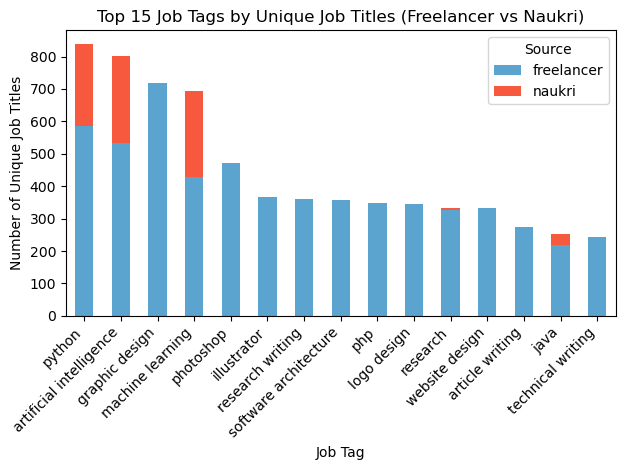

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from langdetect import detect
from collections import Counter

# Load CSV
df = pd.read_csv(r"C:/Users/USER/OneDrive/Desktop/combined_job.csv")

# Drop rows with missing job_title or job_tags
df.dropna(subset=['job_title', 'job_tags'], inplace=True)

# Remove special characters and convert job_tags to lowercase
df['job_tags'] = df['job_tags'].apply(lambda x: re.sub(r'[^a-zA-Z0-9, ]', '', x.lower()))

# Remove non-English job titles
def is_english(text):
    try:
        return detect(text) == 'en'
    except:
        return False

df = df[df['job_title'].apply(is_english)]

# Split job_tags into individual tags
df['job_tags'] = df['job_tags'].str.split(',')

# Explode tags into individual rows
df = df.explode('job_tags')
df['job_tags'] = df['job_tags'].str.strip()

# Optional: Normalize similar tags (basic manual mapping for simplicity)
tag_map = {
    'ml': 'machine learning',
    'machine learning ml': 'machine learning',
    'ai': 'artificial intelligence',
    'web design': 'website design',
    'graphic designing': 'graphic design',
    'ps': 'photoshop'
}
df['job_tags'] = df['job_tags'].replace(tag_map)

# Count unique job titles by tag and source
grouped = df.groupby(['job_tags', 'source'])['job_title'].nunique().unstack(fill_value=0)

# Get top 10 tags by total job count
top_tags = grouped.sum(axis=1).nlargest(15).index
top_data = grouped.loc[top_tags]

# Plotting 
colors = {
    'freelancer': sns.color_palette("Blues", n_colors=10)[5],
    'naukri': sns.color_palette("Reds", n_colors=10)[5]
}

top_data.plot(kind='bar', stacked=True, color=[colors.get(col, '#333') for col in top_data.columns])

plt.title("Top 15 Job Tags by Unique Job Titles (Freelancer vs Naukri)")
plt.xlabel("Job Tag")
plt.ylabel("Number of Unique Job Titles")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Source')
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_14120\2067783782.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_data['salary_pct'] = top_data['salary_usd'] / max_salary * 100


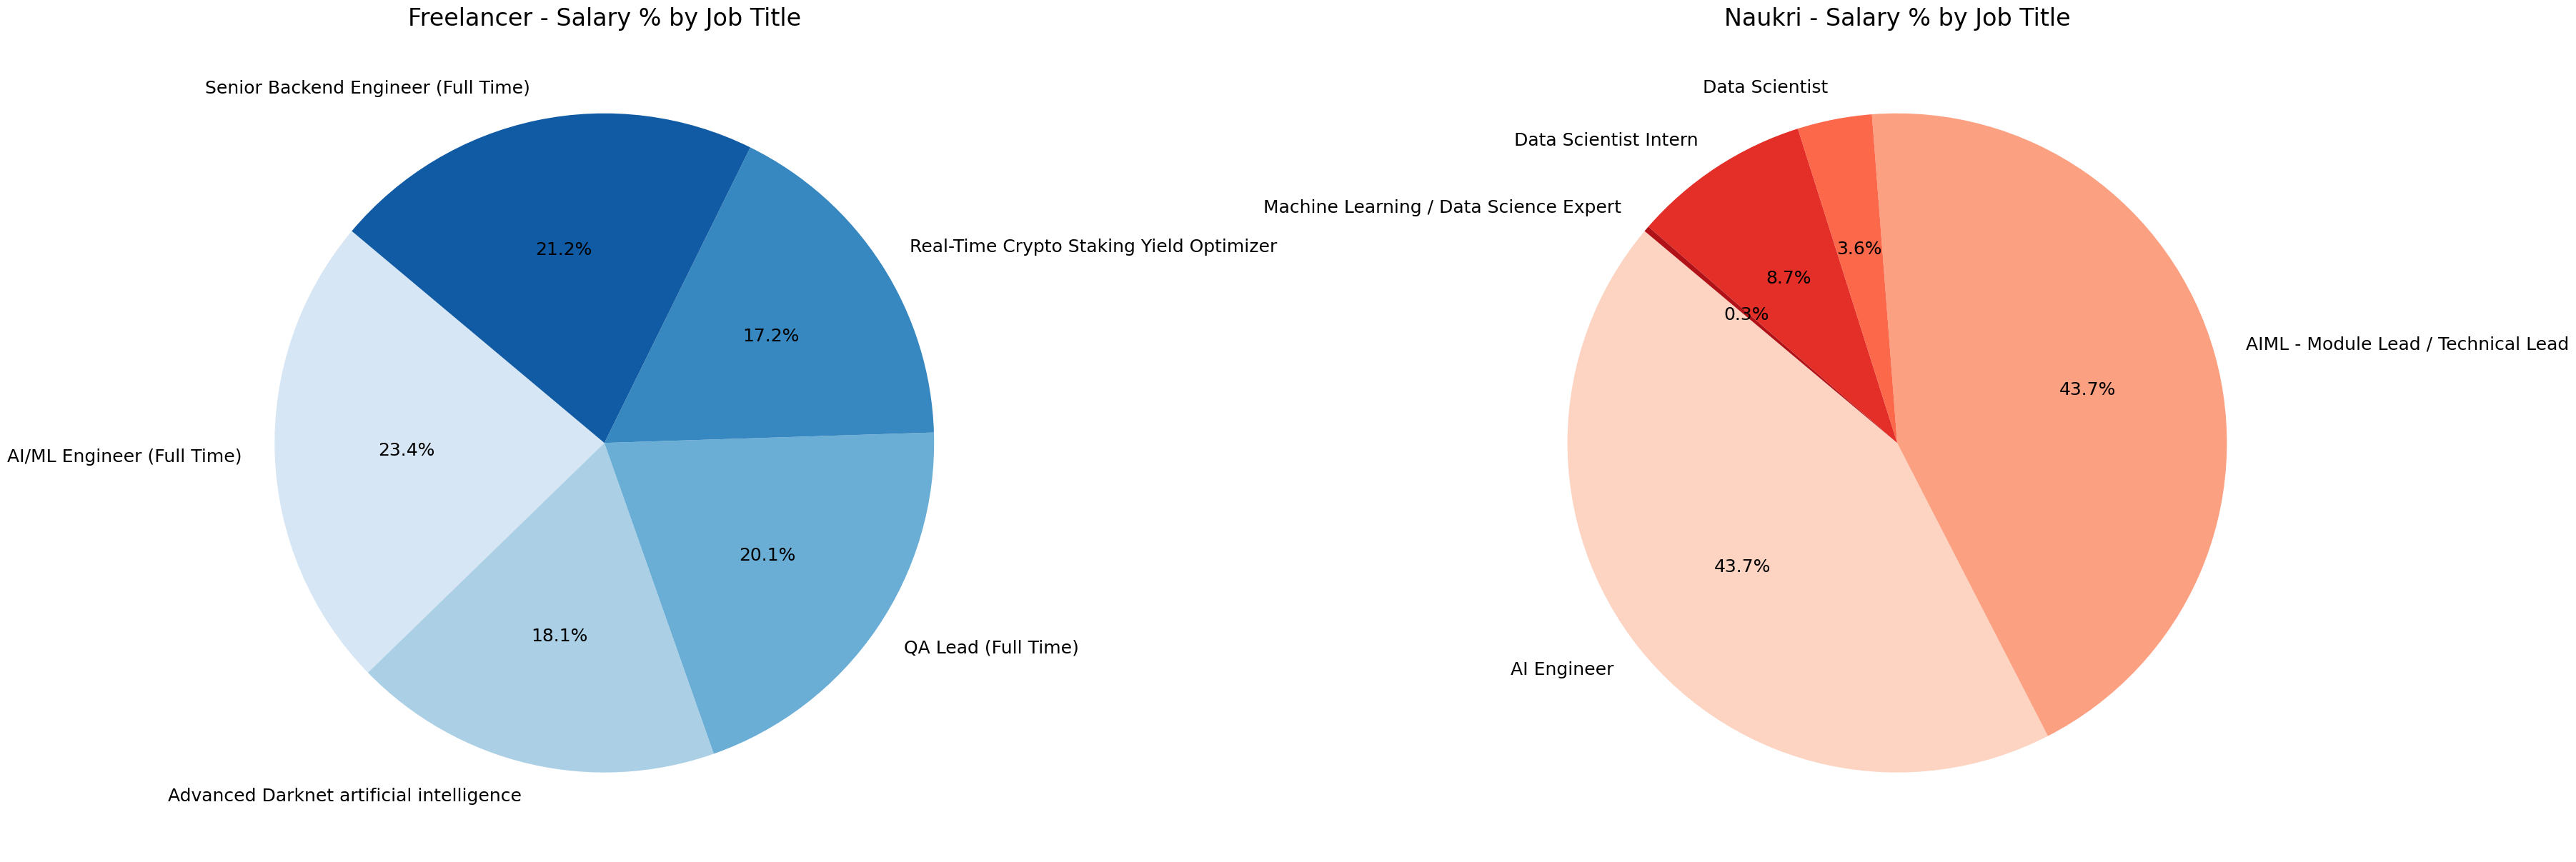

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import hashlib

# Load CSV
df = pd.read_csv(r"C:/Users/USER/OneDrive/Desktop/combined_job.csv")

# Clean data
df = df.dropna(subset=['salary_usd'])

# Remove duplicates using hash
df['hash_key'] = df.apply(lambda row: hashlib.md5(str(row).encode()).hexdigest(), axis=1)
df.drop_duplicates(subset=['hash_key'], inplace=True)
df.drop('hash_key', axis=1, inplace=True)

# Clean job_tags
df['job_tags'] = df['job_tags'].apply(lambda x: re.sub(r'[^a-zA-Z0-9, ]', '', x.lower()) if isinstance(x, str) else '')

# Freelancer 
freelancer_df = df[df['source'].str.lower() == 'freelancer']
freelancer_grouped = freelancer_df.groupby('job_title')['salary_usd'].mean().nlargest(5).reset_index()
freelancer_grouped['salary_pct'] = freelancer_grouped['salary_usd'] / freelancer_grouped['salary_usd'].sum() * 100

# Naukri 
naukri_df = df[df['source'].str.lower() == 'naukri']
naukri_grouped = naukri_df.groupby('job_title')['salary_usd'].mean().nlargest(5).reset_index()
naukri_grouped['salary_pct'] = naukri_grouped['salary_usd'] / naukri_grouped['salary_usd'].sum() * 100

fig, axs = plt.subplots(1, 2, figsize=(24, 12))  # Larger figure, no black background

# Freelancer Pie
axs[0].pie(
    freelancer_grouped['salary_pct'],
    labels=freelancer_grouped['job_title'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("Blues", n_colors=5),
    textprops={'fontsize': 12, 'color': 'black'},  # black text for visibility
    pctdistance=0.7,  # Put percentage labels inside slices
    labeldistance=1.1
)
axs[0].set_title('Freelancer - Salary % by Job Title (Top 5)', fontsize=16, color='black')

# Naukri Pie
axs[1].pie(
    naukri_grouped['salary_pct'],
    labels=naukri_grouped['job_title'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("Reds", n_colors=5),
    textprops={'fontsize': 12, 'color': 'black'},  # black text for visibility
    pctdistance=0.7,
    labeldistance=1.1
)
axs[1].set_title('Naukri - Salary % by Job Title (Top 5)', fontsize=16, color='black')

# Remove facecolor so background is default (white)
for ax in axs:
    ax.set_facecolor('white')

plt.tight_layout()
plt.show()
